========== LOADING TRAIN DATA ==========
Train samples: 399

========== TRAINING MODEL ==========
Training completed!

========== TEST RESULT ==========

01. test_cat_0.jpg       Actual: cat Predict: dog ✗
02. test_cat_1.jpg       Actual: cat Predict: cat ✓
03. test_cat_10.jpg      Actual: cat Predict: dog ✗
04. test_cat_11.jpg      Actual: cat Predict: dog ✗
05. test_cat_12.jpg      Actual: cat Predict: cat ✓
06. test_cat_13.jpg      Actual: cat Predict: dog ✗
07. test_cat_14.jpg      Actual: cat Predict: cat ✓
08. test_cat_15.jpg      Actual: cat Predict: cat ✓
09. test_cat_16.jpg      Actual: cat Predict: cat ✓
10. test_cat_17.jpg      Actual: cat Predict: cat ✓
11. test_cat_18.jpg      Actual: cat Predict: cat ✓
12. test_cat_19.jpg      Actual: cat Predict: cat ✓
13. test_cat_2.jpg       Actual: cat Predict: dog ✗
14. test_cat_20.jpg      Actual: cat Predict: cat ✓
15. test_cat_21.jpg      Actual: cat Predict: cat ✓
16. test_cat_22.jpg      Actual: cat Predict: dog ✗
17. test_cat_2

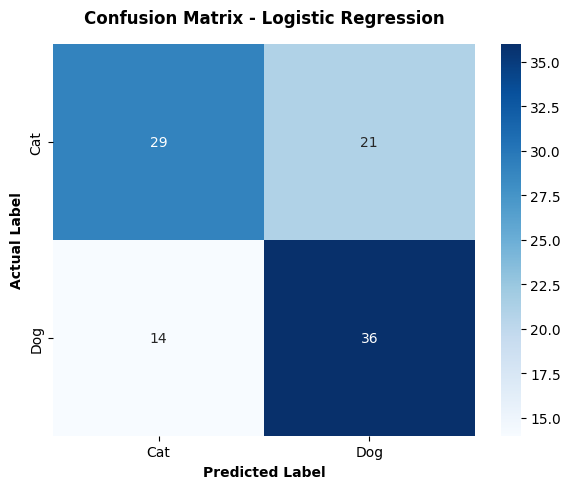

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Tắt warning
warnings.filterwarnings("ignore")

# =====================================================
# HÀM TRÍCH XUẤT ĐẶC TRƯNG
# =====================================================
def Extract_Advanced_Features(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print(f"Không đọc được ảnh: {img_path}")
        return None

    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    avg_color = np.mean(img, axis=(0, 1))

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    return np.hstack((avg_color, contrast, correlation, hog_features))

# =====================================================
# ĐỌC DỮ LIỆU TRAIN (Đọc trực tiếp từ file CSV)
# =====================================================
csv_path = "../data/dog_cat_features.csv"

if not os.path.exists(csv_path):
    print("Không tìm thấy file:", csv_path)
    exit()

print("========== LOADING TRAIN DATA ==========")
df_train = pd.read_csv(csv_path)
print("Train samples:", len(df_train))

X_train = df_train.drop(columns=["Label"]).values
y_train = df_train["Label"].values

# =====================================================
# HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION
# =====================================================
print("\n========== TRAINING MODEL ==========")

# Tạo pipeline chuẩn hóa dữ liệu trước khi đưa vào Logistic Regression
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

model.fit(X_train, y_train)
print("Training completed!")

# =====================================================
# DỰ ĐOÁN TRÊN THƯ MỤC TEST ĐỘC LẬP
# =====================================================
test_dir = "../data/test"

actual = []
predicted = []

print("\n========== TEST RESULT ==========\n")

count = 1
for category in ["cat", "dog"]:
    folder = os.path.join(test_dir, category)
    if not os.path.exists(folder):
        print("Không tìm thấy thư mục:", folder)
        continue

    for file in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, file)
        feature = Extract_Advanced_Features(img_path)

        if feature is None:
            continue

        pred = model.predict([feature])[0]
        actual.append(category)
        predicted.append(pred)

        status = "✓" if pred == category else "✗"
        print(f"{count:02d}. {file:<20} Actual: {category:<3} Predict: {pred:<3} {status}")
        count += 1

# =====================================================
# KẾT QUẢ ĐÁNH GIÁ & BÁO CÁO
# =====================================================
accuracy = accuracy_score(actual, predicted)

# Tính toán các chỉ số của Confusion Matrix
# Cố định nhãn ['cat', 'dog'] => Mèo là 0 (Negative), Chó là 1 (Positive)
cm = confusion_matrix(actual, predicted, labels=['cat', 'dog'])

tn = cm[0, 0] # Actual Cat, Predict Cat
fp = cm[0, 1] # Actual Cat, Predict Dog
fn = cm[1, 0] # Actual Dog, Predict Cat
tp = cm[1, 1] # Actual Dog, Predict Dog

print("\n========================================")
print(f"Kết quả trên tập Test:")
print(f"o Độ chính xác (Accuracy): {accuracy * 100:.2f}%")
print("========================================")
print("\no Ma trận nhầm lẫn chi tiết:")
print(f"  + True Positive (Đoán đúng Chó): {tp}")
print(f"  + True Negative (Đoán đúng Mèo): {tn}")
print(f"  + False Positive (Nhầm Mèo thành Chó): {fp}")
print(f"  + False Negative (Nhầm Chó thành Mèo): {fn}")

# Vẽ biểu đồ Confusion Matrix đồng bộ với các mô hình khác
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.title('Confusion Matrix - Logistic Regression', fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.tight_layout()
plt.show()